## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# Automobile Loan Default
Data Source : https://www.kaggle.com/datasets/saurabhbagchi/dish-network-hackathon/data?select=Train_Dataset.csv

# Problem Statement

[your refined problem statment here]

## Objectives
List the key questions guiding your analysis and modeling:
- What features influence the target variable?
- Can feature engineering improve model performance?
- How do different model versions compare?

# Data Inspection

## Data Dictionary


In [1]:
# organize your imports in this cell
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [2]:
df = pd.read_csv('./Train_Dataset.csv')
df.head()

/var/folders/zr/71j6445d51ggyc5_zkgjz1br0000gn/T/ipykernel_42073/3910647799.py:1: DtypeWarning: Columns (1,7,8,16,17,18,19,20,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./Train_Dataset.csv')


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [3]:
df_cleaned = df.copy()

In [4]:
df_cleaned.shape

(121856, 40)

In [5]:
df_cleaned.duplicated().sum()

0

In [6]:
df_cleaned.dtypes

ID                              int64
Client_Income                  object
Car_Owned                     float64
Bike_Owned                    float64
Active_Loan                   float64
House_Own                     float64
Child_Count                   float64
Credit_Amount                  object
Loan_Annuity                   object
Accompany_Client               object
Client_Income_Type             object
Client_Education               object
Client_Marital_Status          object
Client_Gender                  object
Loan_Contract_Type             object
Client_Housing_Type            object
Population_Region_Relative     object
Age_Days                       object
Employed_Days                  object
Registration_Days              object
ID_Days                        object
Own_House_Age                 float64
Mobile_Tag                      int64
Homephone_Tag                   int64
Workphone_Working               int64
Client_Occupation              object
Client_Famil

In [7]:
# Dealing with Data types
df_cleaned['Client_Income'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    3607
$      15
Name: count, dtype: int64

In [8]:
df_cleaned.loc[df['Client_Income'].astype(str).str.contains(r'\$', regex=True), 'Client_Income']

1586      $
9963      $
22639     $
29426     $
43000     $
69132     $
70322     $
73469     $
73771     $
81745     $
94071     $
102682    $
102927    $
112898    $
116440    $
Name: Client_Income, dtype: object

In [9]:
df_cleaned['Client_Income'] = df_cleaned['Client_Income'].replace(['n', '$'], pd.NA)
df_cleaned['Client_Income'] = pd.to_numeric(df_cleaned['Client_Income'], errors='coerce')

In [10]:
df_cleaned['Client_Income'].isnull().sum()

3622

In [11]:
df_cleaned['Client_Income'].dtype

dtype('float64')

In [12]:
df_cleaned['Credit_Amount'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    3632
$       5
Name: count, dtype: int64

In [13]:
df_cleaned.loc[df_cleaned['Credit_Amount'].astype(str).str.contains(r'\$', regex=True), 'Credit_Amount']

6007      $
10767     $
35677     $
117834    $
120718    $
Name: Credit_Amount, dtype: object

In [14]:
df_cleaned['Credit_Amount'] = df_cleaned['Credit_Amount'].replace(['n', '$'], pd.NA)
df_cleaned['Credit_Amount'] = pd.to_numeric(df_cleaned['Credit_Amount'], errors='coerce')

In [15]:
print(df_cleaned['Credit_Amount'].dtype)
df_cleaned['Credit_Amount'].isnull().sum()

float64


3637

In [16]:
df_cleaned['Loan_Annuity'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    4812
#      13
$       1
Name: count, dtype: int64

In [17]:
df_cleaned.loc[df_cleaned['Loan_Annuity'].astype(str).str.contains('#', regex=False), 'Loan_Annuity']

1085      #VALUE!
2064      #VALUE!
9203      #VALUE!
11076     #VALUE!
35408     #VALUE!
46140     #VALUE!
60431     #VALUE!
76752     #VALUE!
83923     #VALUE!
89100     #VALUE!
100204    #VALUE!
101877    #VALUE!
111556    #VALUE!
Name: Loan_Annuity, dtype: object

In [18]:
df_cleaned['Loan_Annuity'] = df_cleaned['Loan_Annuity'].replace(['n', '$', '#VALUE!'], pd.NA)
df_cleaned['Loan_Annuity'] = pd.to_numeric(df_cleaned['Loan_Annuity'], errors='coerce')

In [19]:
print(df_cleaned['Loan_Annuity'].dtype)
print(df_cleaned['Loan_Annuity'].isnull().sum())

float64
4826


In [20]:
df_cleaned['Population_Region_Relative'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    4857
@       6
#       5
Name: count, dtype: int64

In [21]:
df_cleaned['Population_Region_Relative'] = df_cleaned['Population_Region_Relative'].replace(['n', '@', '#'], pd.NA)
df_cleaned['Population_Region_Relative'] = pd.to_numeric(df_cleaned['Population_Region_Relative'], errors='coerce')

In [22]:
print(df_cleaned['Population_Region_Relative'].dtype)
print(df_cleaned['Population_Region_Relative'].isnull().sum())

float64
4868


In [23]:
df_cleaned['Age_Days'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    3600
x      17
Name: count, dtype: int64

In [24]:
df_cleaned['Age_Days'] = df_cleaned['Age_Days'].replace(['n', 'x'], pd.NA)
df_cleaned['Age_Days'] = pd.to_numeric(df_cleaned['Age_Days'], errors='coerce')

In [25]:
print(df_cleaned['Age_Days'].dtype)
print(df_cleaned['Age_Days'].isnull().sum())

float64
3617


In [26]:
df_cleaned['Employed_Days'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    3649
x      17
Name: count, dtype: int64

In [27]:
df_cleaned['Employed_Days'] = df_cleaned['Employed_Days'].replace(['n', 'x'], pd.NA)
df_cleaned['Employed_Days'] = pd.to_numeric(df_cleaned['Employed_Days'], errors='coerce')

In [28]:
print(df_cleaned['Employed_Days'].dtype)
print(df_cleaned['Employed_Days'].isnull().sum())

float64
3666


In [29]:
df_cleaned['Registration_Days'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    3614
x      17
Name: count, dtype: int64

In [30]:
df_cleaned['Registration_Days'] = df_cleaned['Registration_Days'].replace(['n', 'x'], pd.NA)
df_cleaned['Registration_Days'] = pd.to_numeric(df_cleaned['Registration_Days'], errors='coerce')

In [31]:
print(df_cleaned['Registration_Days'].dtype)
print(df_cleaned['Registration_Days'].isnull().sum())

float64
3631


In [32]:
df_cleaned['ID_Days'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    5968
x      17
Name: count, dtype: int64

In [33]:
df_cleaned['ID_Days'] = df_cleaned['ID_Days'].replace(['n', 'x'], pd.NA)
df_cleaned['ID_Days'] = pd.to_numeric(df_cleaned['ID_Days'], errors='coerce')

In [34]:
print(df_cleaned['ID_Days'].dtype)
print(df_cleaned['ID_Days'].isnull().sum())

float64
5985


In [35]:
df_cleaned['Score_Source_3'].astype(str).str.extract(r'([^0-9.\-])').dropna().value_counts()

0
n    26921
&        1
Name: count, dtype: int64

In [36]:
df_cleaned['Score_Source_3'] = df_cleaned['Score_Source_3'].replace(['n', '&'], pd.NA)
df_cleaned['Score_Source_3'] = pd.to_numeric(df_cleaned['Score_Source_3'], errors='coerce')

In [37]:
print(df_cleaned['Score_Source_3'].dtype)
print(df_cleaned['Score_Source_3'].isnull().sum())

float64
26922


In [38]:
df_cleaned.dtypes

ID                              int64
Client_Income                 float64
Car_Owned                     float64
Bike_Owned                    float64
Active_Loan                   float64
House_Own                     float64
Child_Count                   float64
Credit_Amount                 float64
Loan_Annuity                  float64
Accompany_Client               object
Client_Income_Type             object
Client_Education               object
Client_Marital_Status          object
Client_Gender                  object
Loan_Contract_Type             object
Client_Housing_Type            object
Population_Region_Relative    float64
Age_Days                      float64
Employed_Days                 float64
Registration_Days             float64
ID_Days                       float64
Own_House_Age                 float64
Mobile_Tag                      int64
Homephone_Tag                   int64
Workphone_Working               int64
Client_Occupation              object
Client_Famil

In [39]:
# handle missing values
df_cleaned.isnull().sum()

ID                                0
Client_Income                  3622
Car_Owned                      3581
Bike_Owned                     3624
Active_Loan                    3635
House_Own                      3661
Child_Count                    3638
Credit_Amount                  3637
Loan_Annuity                   4826
Accompany_Client               1746
Client_Income_Type             3701
Client_Education               3645
Client_Marital_Status          3473
Client_Gender                  2413
Loan_Contract_Type             3651
Client_Housing_Type            3687
Population_Region_Relative     4868
Age_Days                       3617
Employed_Days                  3666
Registration_Days              3631
ID_Days                        5985
Own_House_Age                 80095
Mobile_Tag                        0
Homephone_Tag                     0
Workphone_Working                 0
Client_Occupation             41435
Client_Family_Members          2410
Cleint_City_Rating          

In [40]:
df_cleaned.groupby(df_cleaned['Social_Circle_Default'].isnull())['Default'].mean()

Social_Circle_Default
False    0.069600
True     0.091623
Name: Default, dtype: float64

In [41]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df_cleaned['Social_Circle_Default'].isnull(), df_cleaned['Default'])
print(table)
chi2, p, dof, expected = chi2_contingency(table)
print('p-value:', p)

Default                    0     1
Social_Circle_Default             
False                  55757  4171
True                   56254  5674
p-value: 4.232601741858239e-45


In [42]:
df_cleaned['Social_Circle_Default'].describe()

count    59928.000000
mean         0.117428
std          0.107974
min          0.000000
25%          0.057700
50%          0.088700
75%          0.148500
max          1.000000
Name: Social_Circle_Default, dtype: float64

In [43]:
df_cleaned['Social_Circle_Default'] = df_cleaned['Social_Circle_Default'].fillna(df_cleaned['Social_Circle_Default'].median())

In [44]:
 df_cleaned['Credit_Bureau'].describe()

count    103316.000000
mean          1.891082
std           1.861921
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          22.000000
Name: Credit_Bureau, dtype: float64

In [45]:
df_cleaned['Credit_Bureau'].value_counts().sort_index().head(15)

Credit_Bureau
0.0     28003
1.0     24572
2.0     19606
3.0     13102
4.0      7978
5.0      4671
6.0      2660
7.0      1421
8.0       832
9.0       422
10.0       10
11.0       11
12.0        2
13.0        6
14.0        6
Name: count, dtype: int64

In [46]:
df_cleaned['Credit_Bureau'] = df_cleaned['Credit_Bureau'].fillna(0)

In [47]:
df_cleaned.groupby(df_cleaned['Score_Source_3'].isnull())['Default'].mean()

Score_Source_3
False    0.078570
True     0.088626
Name: Default, dtype: float64

In [48]:
df_cleaned['Score_Source_3'] = df_cleaned['Score_Source_3'].fillna(df_cleaned['Score_Source_3'].median())

In [49]:
df_cleaned.groupby('House_Own')['Own_House_Age'].apply(lambda s: s.isnull().mean() * 100).round(1)

House_Own
0.0    65.2
1.0    66.0
Name: Own_House_Age, dtype: float64

In [50]:
df_cleaned = df_cleaned.drop(columns=['Own_House_Age', 'ID'])

In [51]:
(df_cleaned.groupby('Client_Income_Type')['Client_Occupation'].apply(lambda s: s.isnull().mean() * 100).round(1))

Client_Income_Type
Businessman          0.0
Commercial          20.5
Govt Job            21.0
Maternity leave     50.0
Retired            100.0
Service             19.1
Student             12.5
Unemployed         100.0
Name: Client_Occupation, dtype: float64

In [52]:
df_cleaned['Client_Occupation'] = df_cleaned['Client_Occupation'].fillna('Not Employed')

In [53]:
print(df_cleaned['Client_Occupation'].isnull().sum())
print(df_cleaned['Client_Occupation'].value_counts().head())

0
Client_Occupation
Not Employed    41435
Laborers        21024
Sales           12136
Core            10611
Managers         8099
Name: count, dtype: int64


In [54]:
df_cleaned.groupby(df_cleaned['Score_Source_1'].isnull())['Default'].mean()

Score_Source_1
False    0.073782
True     0.086192
Name: Default, dtype: float64

In [55]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df_cleaned['Score_Source_1'].isnull(), df_cleaned['Default'])
print(table)
chi2, p, dof, expected = chi2_contingency(table)
print('p-value:', p)

Default             0     1
Score_Source_1             
False           49109  3912
True            62902  5933
p-value: 3.5413337797154843e-15


In [56]:
df_cleaned['Score_Source_1'] = df_cleaned['Score_Source_1'].fillna(df_cleaned['Score_Source_1'].median())

In [57]:
df_cleaned.isnull().sum().sort_values(ascending=False)

ID_Days                       5985
Score_Source_2                5686
Population_Region_Relative    4868
Loan_Annuity                  4826
Client_Income_Type            3701
Client_Housing_Type           3687
Employed_Days                 3666
Phone_Change                  3664
Application_Process_Hour      3663
House_Own                     3661
Loan_Contract_Type            3651
Client_Education              3645
Child_Count                   3638
Credit_Amount                 3637
Active_Loan                   3635
Registration_Days             3631
Bike_Owned                    3624
Client_Income                 3622
Age_Days                      3617
Type_Organization             3609
Car_Owned                     3581
Client_Marital_Status         3473
Application_Process_Day       2428
Client_Gender                 2413
Client_Family_Members         2410
Cleint_City_Rating            2409
Accompany_Client              1746
Score_Source_1                   0
Credit_Bureau       

In [58]:
df_cleaned['Score_Source_2'] = df_cleaned['Score_Source_2'].fillna(df_cleaned['Score_Source_2'].median())

In [59]:
df_cleaned = df_cleaned.drop(columns=['Phone_Change', 'Application_Process_Day', 'Application_Process_Hour'])

In [60]:
df_cleaned.isnull().sum().sort_values(ascending=False).head(15)


ID_Days                       5985
Population_Region_Relative    4868
Loan_Annuity                  4826
Client_Income_Type            3701
Client_Housing_Type           3687
Employed_Days                 3666
House_Own                     3661
Loan_Contract_Type            3651
Client_Education              3645
Child_Count                   3638
Credit_Amount                 3637
Active_Loan                   3635
Registration_Days             3631
Bike_Owned                    3624
Client_Income                 3622
dtype: int64

In [61]:
critical_cols = ['Client_Income', 'Credit_Amount']
rows_before = len(df_cleaned)
rows_after = len(df_cleaned.dropna(subset=critical_cols))
print(f'Rows lost dropping only Client_Income & Credit_Amount nulls: {rows_before - rows_after} ({(rows_before-rows_after)/rows_before*100:.1f}%)')

Rows lost dropping only Client_Income & Credit_Amount nulls: 7148 (5.9%)


In [62]:
critical_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity']
rows_before = len(df_cleaned)
rows_after = len(df_cleaned.dropna(subset=critical_cols))
print(f'Rows lost dropping Client_Income, Credit_Amount & Loan_Annuity nulls: {rows_before - rows_after} ({(rows_before-rows_after)/rows_before*100:.1f}%)')

Rows lost dropping Client_Income, Credit_Amount & Loan_Annuity nulls: 11677 (9.6%)


In [63]:
critical_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity']
df_cleaned = df_cleaned.dropna(subset=critical_cols)

In [64]:
df_cleaned.shape
df_cleaned.isnull().sum().sort_values(ascending=False).head(15)

ID_Days                       5421
Population_Region_Relative    4406
Client_Income_Type            3360
Client_Housing_Type           3348
Employed_Days                 3330
Active_Loan                   3319
House_Own                     3305
Loan_Contract_Type            3289
Bike_Owned                    3289
Client_Education              3280
Child_Count                   3280
Age_Days                      3276
Registration_Days             3273
Car_Owned                     3254
Type_Organization             3254
dtype: int64

In [65]:
df['Default'].value_counts(normalize=True)

Default
0    0.919208
1    0.080792
Name: proportion, dtype: float64

In [66]:
(df_cleaned['Employed_Days'] == 365243).sum()

19069

In [67]:
pd.crosstab(df_cleaned['Employed_Days'] == 365243, df_cleaned['Client_Occupation'] == 'Not Employed')

Client_Occupation,False,True
Employed_Days,,
False,72741,18369
True,2,19067


In [68]:
df_cleaned.loc[df_cleaned['Employed_Days'] == 365243, 'Employed_Days'] = pd.NA
df_cleaned['Employed_Days'] = pd.to_numeric(df_cleaned['Employed_Days'], errors='coerce')
df_cleaned['Employed_Days'] = df_cleaned['Employed_Days'].fillna(df_cleaned['Employed_Days'].median())

In [69]:
print(df_cleaned['Employed_Days'].isnull().sum())
print(df_cleaned['Employed_Days'].describe())

0
count    110179.000000
mean       2227.664101
std        2094.545709
min           0.000000
25%         961.000000
50%        1646.000000
75%        2694.000000
max       17546.000000
Name: Employed_Days, dtype: float64


In [70]:
median_cols = ['ID_Days', 'Population_Region_Relative', 'Age_Days', 'Registration_Days',
               'Child_Count', 'Client_Family_Members']
for col in median_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

mode_cols = ['Active_Loan', 'House_Own', 'Bike_Owned', 'Car_Owned', 'Cleint_City_Rating',
             'Client_Income_Type', 'Client_Housing_Type', 'Loan_Contract_Type',
             'Client_Education', 'Type_Organization', 'Client_Marital_Status',
             'Client_Gender', 'Accompany_Client']
for col in mode_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

In [71]:
df_cleaned.isnull().sum().sum()

0

In [72]:
#inconsistencies

In [73]:
numeric_cols = df_cleaned.select_dtypes(include='number').columns

In [74]:
print("Check complete.")
print("Columns with negative values:", [col for col in numeric_cols if (df_cleaned[col] < 0).any()])

Check complete.
Columns with negative values: []


In [75]:
categorical_cols = df_cleaned.select_dtypes(include='object').columns
for col in categorical_cols:
    print(col, ':', df_cleaned[col].unique())
    print()

Accompany_Client : ['Alone' 'Relative' 'Others' 'Kids' 'Partner' '##' 'Group']

Client_Income_Type : ['Commercial' 'Service' 'Retired' 'Govt Job' 'Student' 'Unemployed'
 'Maternity leave' 'Businessman']

Client_Education : ['Secondary' 'Graduation' 'Graduation dropout' 'Junior secondary'
 'Post Grad']

Client_Marital_Status : ['M' 'W' 'S' 'D']

Client_Gender : ['Male' 'Female' 'XNA']

Loan_Contract_Type : ['CL' 'RL']

Client_Housing_Type : ['Home' 'Family' 'Office' 'Municipal' 'Rental' 'Shared']

Client_Occupation : ['Sales' 'Not Employed' 'Realty agents' 'Laborers' 'Core' 'Drivers'
 'Managers' 'Accountants' 'High skill tech' 'Cleaning' 'HR'
 'Waiters/barmen' 'Low-skill Laborers' 'Medicine' 'Cooking'
 'Private service' 'Security' 'IT' 'Secretaries']

Client_Permanent_Match_Tag : ['Yes' 'No']

Client_Contact_Work_Tag : ['Yes' 'No']

Type_Organization : ['Self-employed' 'Government' 'XNA' 'Business Entity Type 3' 'Other'
 'Industry: type 3' 'Business Entity Type 2' 'Business Entity Type 

In [76]:
(df_cleaned['Accompany_Client'] == '##').sum()

11

In [77]:
(df_cleaned['Client_Gender'] == 'XNA').sum()

3

In [78]:
(df_cleaned['Type_Organization'] == 'XNA').sum()

19057

In [79]:
pd.crosstab(df_cleaned['Type_Organization'] == 'XNA', df_cleaned['Client_Occupation'] == 'Not Employed')

Client_Occupation,False,True
Type_Organization,,
False,72741,18381
True,2,19055


In [80]:
df_cleaned['Type_Organization'] = df_cleaned['Type_Organization'].replace('XNA', 'Not Employed')
df_cleaned.loc[df_cleaned['Accompany_Client'] == '##', 'Accompany_Client'] = df_cleaned['Accompany_Client'].mode()[0]
df_cleaned.loc[df_cleaned['Client_Gender'] == 'XNA', 'Client_Gender'] = df_cleaned['Client_Gender'].mode()[0]

In [81]:
print((df_cleaned['Type_Organization'] == 'XNA').sum())
print((df_cleaned['Accompany_Client'] == '##').sum())
print((df_cleaned['Client_Gender'] == 'XNA').sum())

0
0
0


In [82]:
#Outliers

df_cleaned.describe()

,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Population_Region_Relative,Age_Days,...,Homephone_Tag,Workphone_Working,Client_Family_Members,Cleint_City_Rating,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Credit_Bureau,Default
count,1.101790e+05,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,...,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000,110179.000000
mean,1.686687e+04,0.332704,0.322085,0.484766,0.701549,0.405359,60035.896789,2719.374171,0.022611,16022.378266,...,0.200111,0.280716,2.151154,2.029352,0.503106,0.520784,0.516779,0.102910,1.605161,0.080986
std,1.167530e+04,0.471184,0.467277,0.499770,0.457580,0.721961,40359.132374,1458.509422,0.426182,4301.325794,...,0.400085,0.449351,0.904569,0.499170,0.139336,0.757774,0.171794,0.077273,1.845781,0.272815
min,2.565000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,4500.000000,217.350000,0.000533,7676.000000,...,0.000000,0.000000,1.000000,1.000000,0.014568,0.000005,0.000527,0.000000,0.000000,0.000000
25%,1.125000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,27000.000000,1657.350000,0.010032,12518.000000,...,0.000000,0.000000,2.000000,2.000000,0.504657,0.400899,0.424130,0.088700,0.000000,0.000000
50%,1.440000e+04,0.000000,0.000000,0.000000,1.000000,0.000000,51486.750000,2498.400000,0.018850,15741.000000,...,0.000000,0.000000,2.000000,2.000000,0.504657,0.564978,0.537070,0.088700,1.000000,0.000000
75%,2.025000e+04,1.000000,1.000000,1.000000,1.000000,1.000000,80865.000000,3465.450000,0.026392,19541.000000,...,0.000000,1.000000,3.000000,2.000000,0.504657,0.659514,0.631355,0.088700,3.000000,0.000000
max,1.800009e+06,1.000000,1.000000,1.000000,1.000000,19.000000,405000.000000,22500.000000,100.000000,25201.000000,...,1.000000,1.000000,16.000000,3.000000,0.945741,100.000000,0.896010,1.000000,22.000000,1.000000


In [83]:
#Outliers in score source 2 column
(df_cleaned['Score_Source_2'] > 1).sum()

6

In [84]:
df_cleaned.loc[df_cleaned['Score_Source_2'] > 1, 'Score_Source_2']

44468     100.0
73097     100.0
105522    100.0
109378    100.0
114099    100.0
119243    100.0
Name: Score_Source_2, dtype: float64

In [85]:
df_cleaned.loc[df_cleaned['Score_Source_2'] > 1, 'Score_Source_2'] = df_cleaned['Score_Source_2'].median()

In [86]:
df_cleaned['Score_Source_2'].max()

0.854999666

In [87]:
#Outliers in Population_Region_Relative column
(df_cleaned['Population_Region_Relative'] > 1).sum()

2

In [88]:
df_cleaned.loc[df_cleaned['Population_Region_Relative'] > 1, 'Population_Region_Relative']

33053    100.0
52949    100.0
Name: Population_Region_Relative, dtype: float64

In [89]:
df_cleaned.loc[df_cleaned['Population_Region_Relative'] > 1, 'Population_Region_Relative'] = df_cleaned['Population_Region_Relative'].median()

In [90]:
df_cleaned['Population_Region_Relative'].max()

0.072508

In [91]:
#Outliers in child count
df_cleaned['Child_Count'].value_counts().sort_index(ascending=False).head(10)

Child_Count
19.0      1
14.0      4
12.0      1
10.0      3
9.0       1
8.0       2
7.0       4
6.0      11
5.0      33
4.0     147
Name: count, dtype: int64

In [92]:
#Will not change anything

In [93]:
df_cleaned['Client_Income'].sort_values(ascending=False).head(15)

12854     1800009.00
117968     675000.00
106150     450000.00
48942      450000.00
13867      450000.00
101822     395005.95
1722       382500.00
50358      337500.00
60190      225000.00
32314      225000.00
112979     225000.00
58025      225000.00
97968      225000.00
63028      225000.00
58726      225000.00
Name: Client_Income, dtype: float64

In [94]:
df_cleaned['Credit_Amount'].sort_values(ascending=False).head(15)

8651      405000.00
48229     405000.00
75170     405000.00
102124    403103.25
37029     386001.90
82702     329968.80
92988     315000.00
23515     315000.00
65112     315000.00
109603    315000.00
113847    315000.00
83169     307557.90
91273     293166.00
16988     292500.00
80238     270000.00
Name: Credit_Amount, dtype: float64

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [95]:
# Target
print(df_cleaned['Default'].value_counts())
print(df_cleaned['Default'].value_counts(normalize=True) * 100)

Default
0    101256
1      8923
Name: count, dtype: int64
Default
0    91.901361
1     8.098639
Name: proportion, dtype: float64


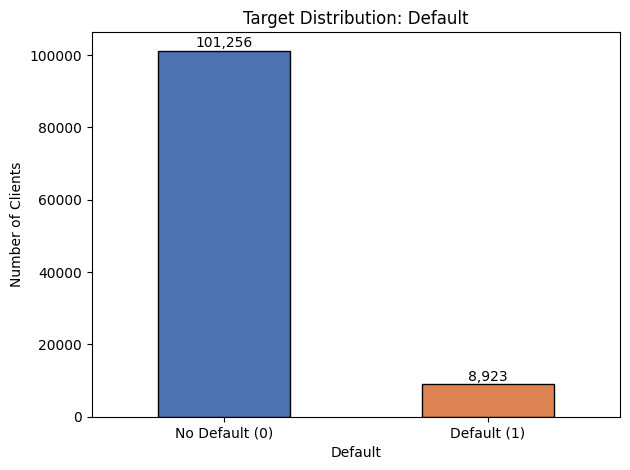

In [96]:

ax = df_cleaned['Default'].value_counts().sort_index().plot(
    kind='bar', color=['#4C72B0', '#DD8452'], edgecolor='black'
)
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
ax.set_ylabel('Number of Clients')
ax.set_title('Target Distribution: Default')
for i, v in enumerate(df_cleaned['Default'].value_counts().sort_index()):
    ax.text(i, v + 1000, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()

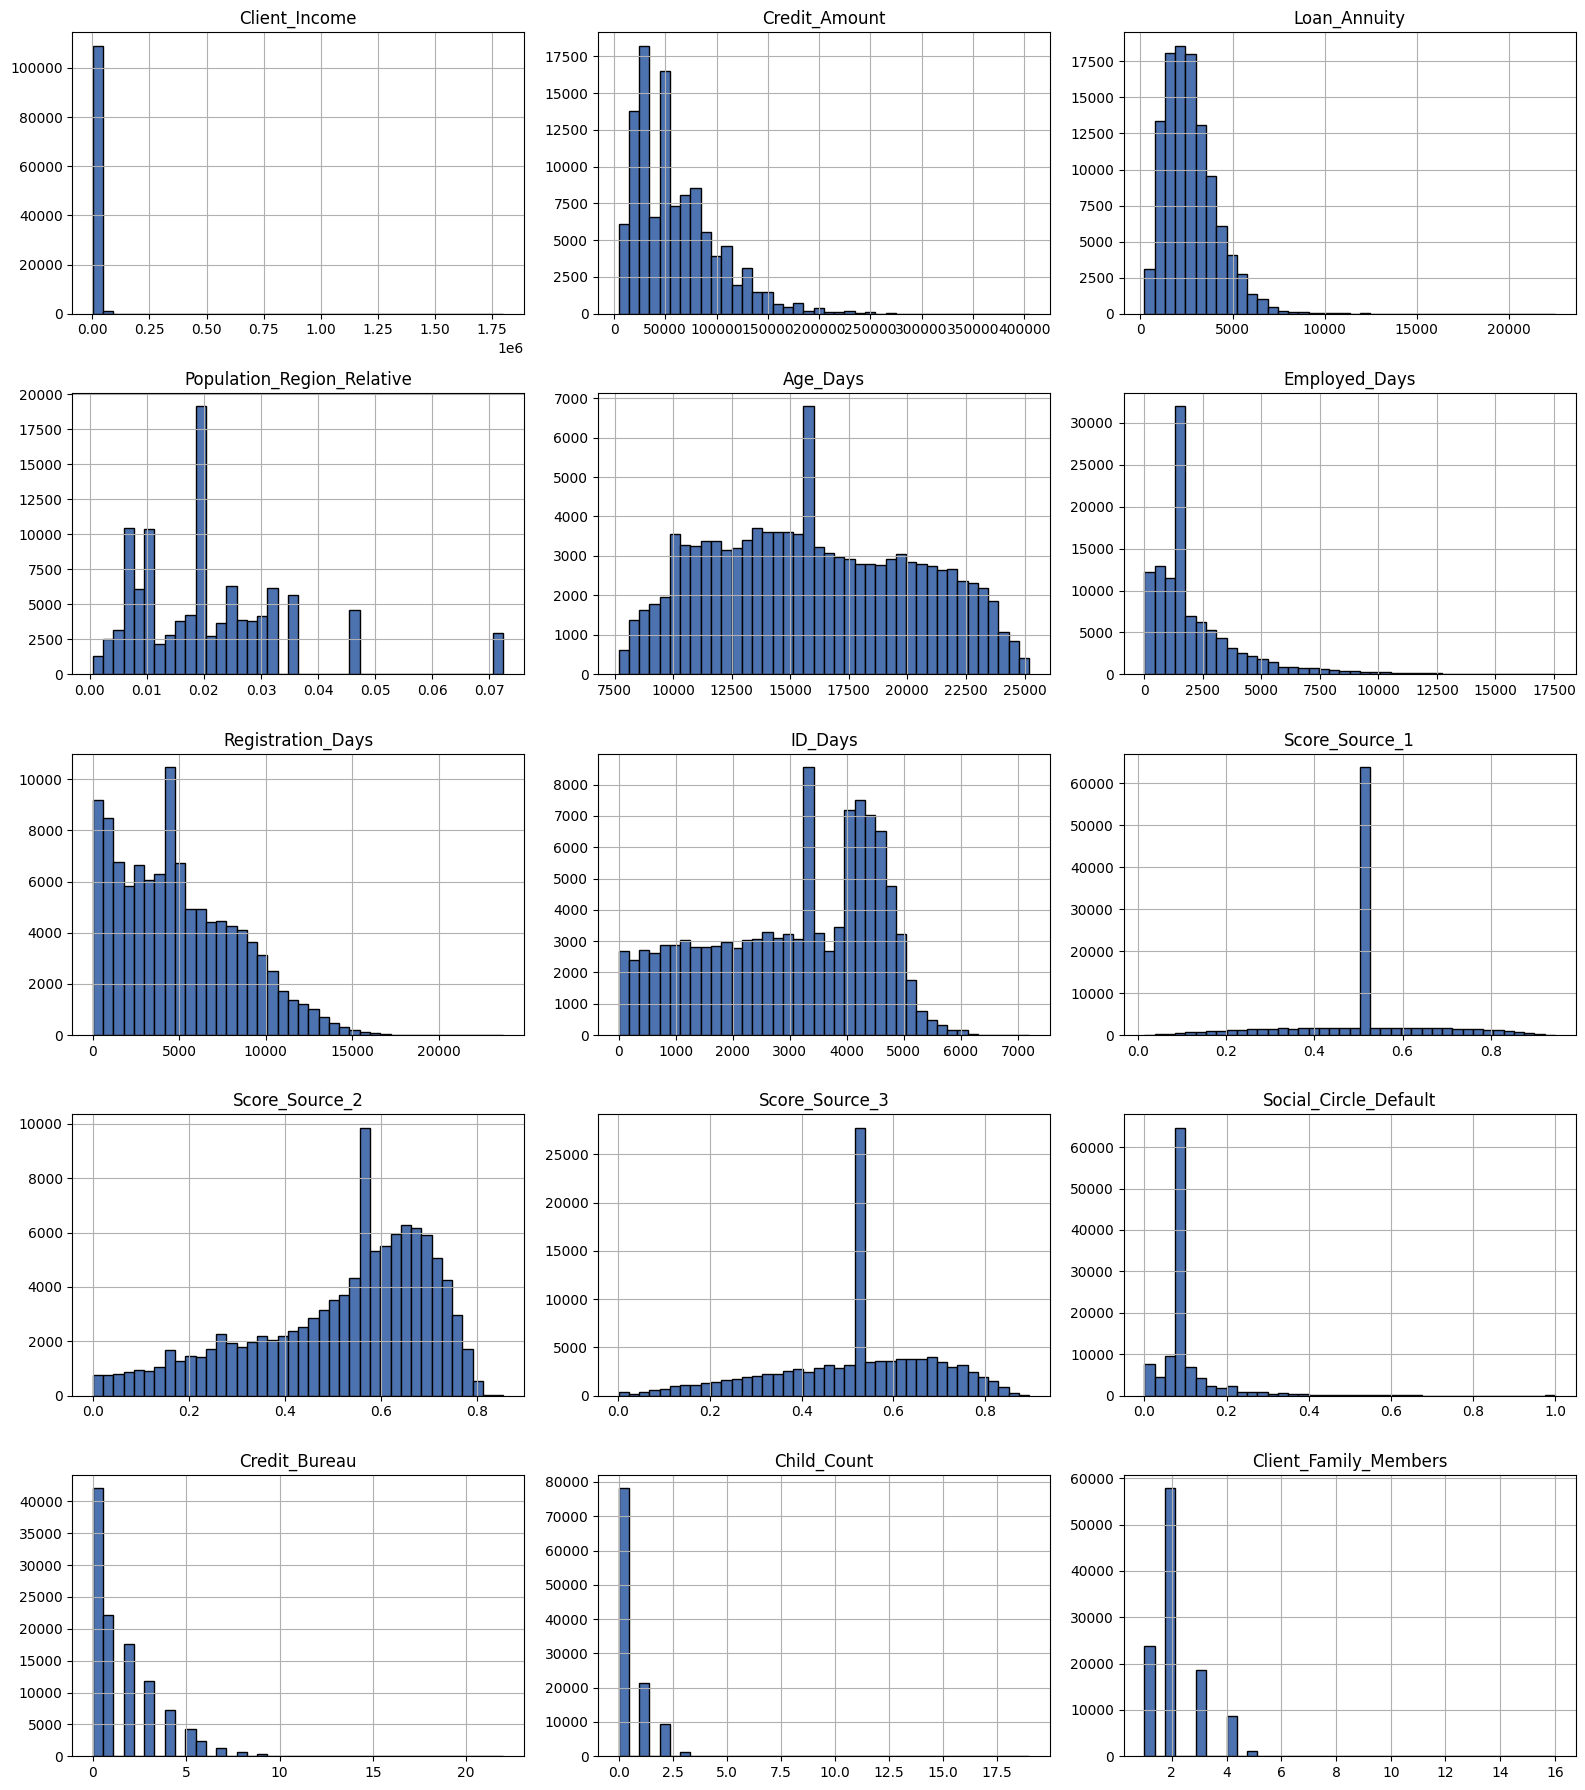

In [97]:
continuous_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative',
                    'Age_Days', 'Employed_Days', 'Registration_Days', 'ID_Days',
                    'Score_Source_1', 'Score_Source_2', 'Score_Source_3',
                    'Social_Circle_Default', 'Credit_Bureau', 'Child_Count', 'Client_Family_Members']

fig, axes = plt.subplots(5, 3, figsize=(16, 18))
for ax, col in zip(axes.flatten(), continuous_cols):
    df_cleaned[col].hist(bins=40, ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

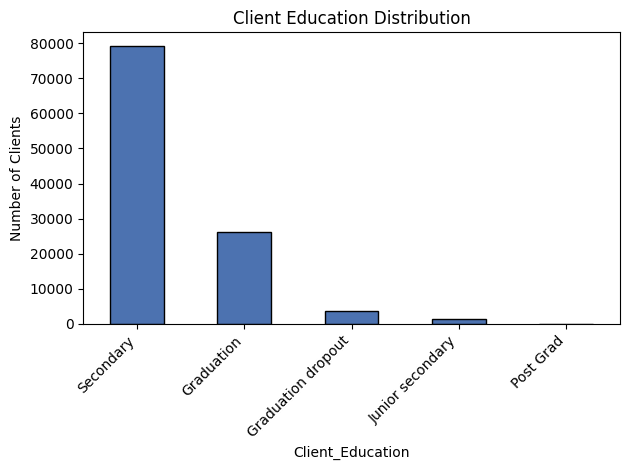

In [98]:
df_cleaned['Client_Education'].value_counts().plot(kind='bar', color='#4C72B0', edgecolor='black')
plt.title('Client Education Distribution')
plt.ylabel('Number of Clients')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

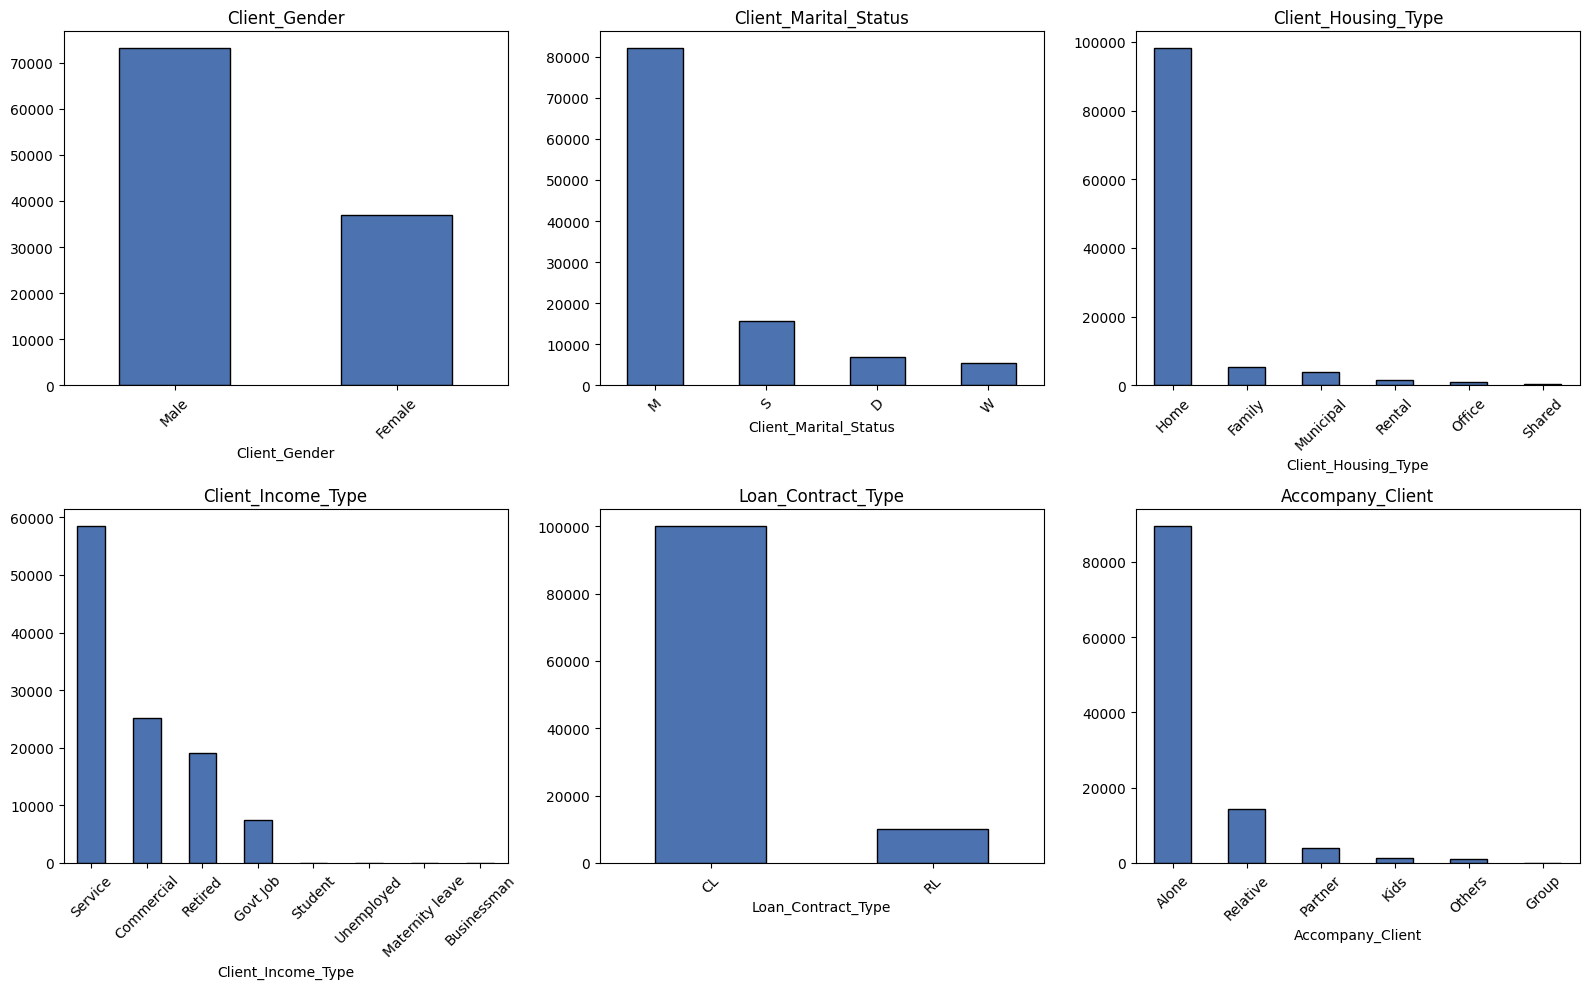

In [99]:
categorical_cols = ['Client_Gender', 'Client_Marital_Status', 'Client_Housing_Type',
                     'Client_Income_Type', 'Loan_Contract_Type', 'Accompany_Client']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), categorical_cols):
    df_cleaned[col].value_counts().plot(kind='bar', ax=ax, color='#4C72B0', edgecolor='black')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [100]:
continuous_cols = ['Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative',
                    'Age_Days', 'Employed_Days', 'Registration_Days', 'ID_Days',
                    'Score_Source_1', 'Score_Source_2', 'Score_Source_3',
                    'Social_Circle_Default', 'Credit_Bureau', 'Child_Count', 'Client_Family_Members',
                    'Default']

corr_matrix = df_cleaned[continuous_cols].corr()
corr_matrix

,Client_Income,Credit_Amount,Loan_Annuity,Population_Region_Relative,Age_Days,Employed_Days,Registration_Days,ID_Days,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Credit_Bureau,Child_Count,Client_Family_Members,Default
Client_Income,1.000000,0.324638,0.400875,0.154241,-0.050866,0.047326,-0.056899,-0.023360,0.052272,0.128356,-0.058157,0.086111,0.039827,0.024294,0.027691,-0.021951
Credit_Amount,0.324638,1.000000,0.768908,0.100872,0.053509,0.086829,-0.008664,0.005724,0.112470,0.126631,0.032702,0.058025,-0.025593,-0.000680,0.058982,-0.030940
Loan_Annuity,0.400875,0.768908,1.000000,0.115501,-0.009826,0.056763,-0.037084,-0.010996,0.082621,0.120187,0.022358,0.070226,-0.006496,0.020514,0.072291,-0.013295
Population_Region_Relative,0.154241,0.100872,0.115501,1.000000,0.033624,-0.005619,0.049928,0.003075,0.064625,0.193758,-0.002831,0.177103,-0.000245,-0.030764,-0.029288,-0.034948
Age_Days,-0.050866,0.053509,-0.009826,0.033624,1.000000,0.175370,0.318157,0.262509,0.353806,0.087219,0.173355,0.001264,0.076967,-0.315415,-0.269429,-0.074281
Employed_Days,0.047326,0.086829,0.056763,-0.005619,0.175370,1.000000,0.108884,0.041709,0.130258,0.084738,0.085785,0.006588,0.017153,-0.026428,0.002770,-0.063474
Registration_Days,-0.056899,-0.008664,-0.037084,0.049928,0.318157,0.108884,1.000000,0.096686,0.110697,0.058877,0.093838,0.001711,0.021002,-0.171847,-0.164689,-0.038475
ID_Days,-0.023360,0.005724,-0.010996,0.003075,0.262509,0.041709,0.096686,1.000000,0.087160,0.049098,0.113907,0.010930,0.058720,0.022459,0.017125,-0.051026
Score_Source_1,0.052272,0.112470,0.082621,0.064625,0.353806,0.130258,0.110697,0.087160,1.000000,0.135229,0.108896,0.038539,0.019052,-0.094356,-0.066919,-0.095208
Score_Source_2,0.128356,0.126631,0.120187,0.193758,0.087219,0.084738,0.058877,0.049098,0.135229,1.000000,0.090398,0.080950,-0.007694,-0.013859,0.000468,-0.150706


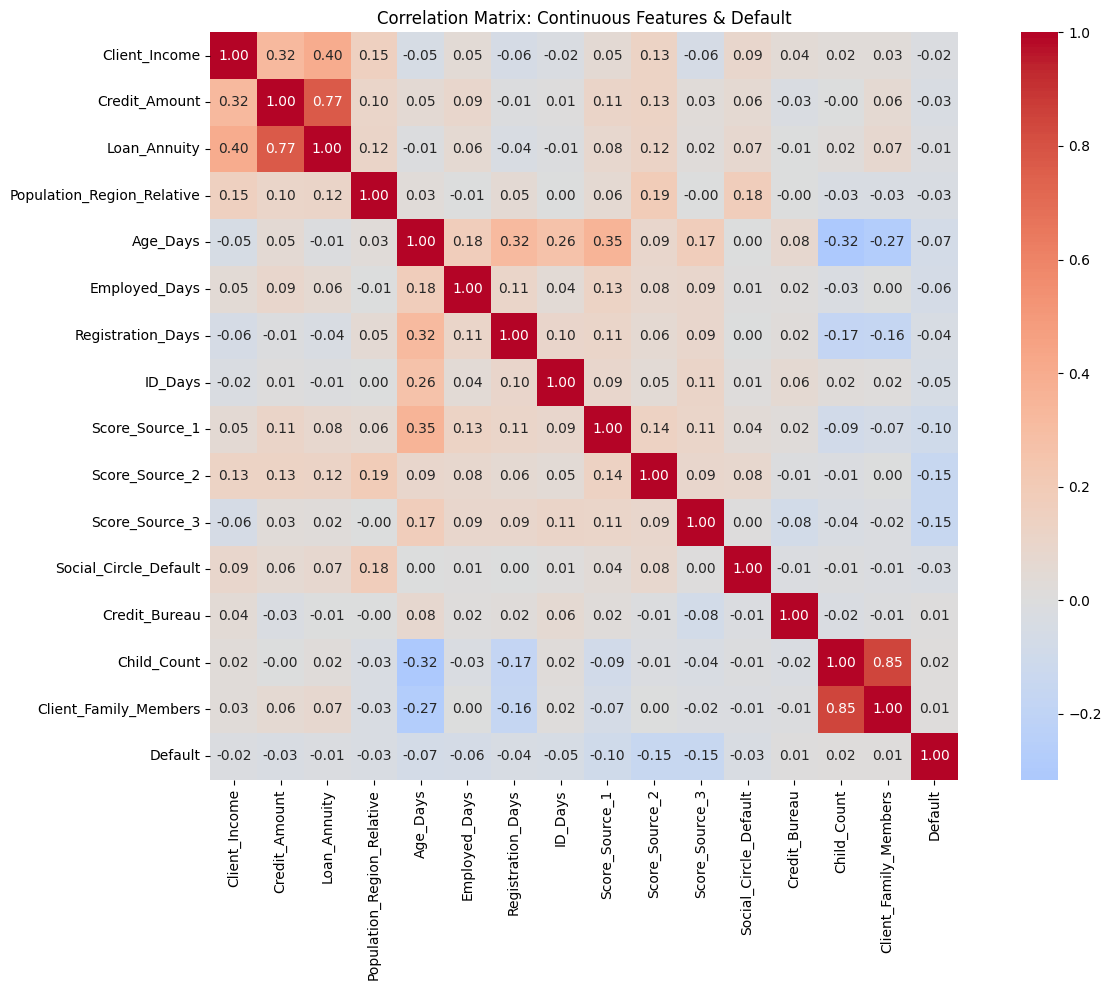

In [101]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix: Continuous Features & Default')
plt.tight_layout()
plt.show()

In [102]:
table = pd.crosstab(df_cleaned['Client_Education'], df_cleaned['Default'])
chi2, p, dof, expected = chi2_contingency(table)
print(table)
print('p-value:', p)

Default                 0     1
Client_Education               
Graduation          24730  1328
Graduation dropout   3273   305
Junior secondary     1194   136
Post Grad              59     1
Secondary           72000  7153
p-value: 6.2662263839004105e-90


In [103]:
categorical_cols = ['Client_Gender', 'Client_Marital_Status', 'Client_Housing_Type',
                     'Client_Income_Type', 'Client_Education', 'Loan_Contract_Type',
                     'Accompany_Client', 'Client_Occupation', 'Type_Organization',
                     'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag']

results = []
for col in categorical_cols:
    table = pd.crosstab(df_cleaned[col], df_cleaned['Default'])
    chi2, p, dof, expected = chi2_contingency(table)
    results.append({'Column': col, 'Chi2': chi2, 'p-value': p, 'Significant (p<0.05)': p < 0.05})

chi_square_summary = pd.DataFrame(results).sort_values('p-value')
chi_square_summary

,Column,Chi2,p-value,Significant (p<0.05)
7,Client_Occupation,655.506155,1.542407e-127,True
8,Type_Organization,637.249634,5.541492e-99,True
4,Client_Education,421.505808,6.266226e-90,True
3,Client_Income_Type,403.579147,4.073421e-83,True
0,Client_Gender,289.647013,5.935661e-65,True
9,Client_Permanent_Match_Tag,213.819262,2.016722e-48,True
2,Client_Housing_Type,149.975265,1.351423e-30,True
5,Loan_Contract_Type,85.748053,2.043854e-20,True
10,Client_Contact_Work_Tag,81.249077,1.989885e-19,True
1,Client_Marital_Status,84.108573,4.031717e-18,True


# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**